# NetSentry — Exploratory Data Analysis

Understand the data **before** modelling: class balance, missingness, which
features separate attacks, and where leakage hides.

> **Synthetic data.** To stay reproducible without the licensed CIC-IDS2017
> download, this notebook uses NetSentry's schema-faithful synthetic generator.
> The numbers illustrate the *methodology*; they are not real-world results. To
> reproduce on the real data, run `netsentry download` + `netsentry prep` and
> load `data/processed/clean.parquet` instead of generating below. Findings are
> distilled in `docs/EDA_SUMMARY.md`.

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from netsentry.config import load_settings
from netsentry.data import schema
from netsentry.data.clean import BINARY_TARGET, MULTICLASS_TARGET, clean_dataframe
from netsentry.data.synthetic import generate_synthetic

warnings.filterwarnings("ignore")

settings = load_settings()
df = clean_dataframe(generate_synthetic(settings, rows=40000, seed=42), settings)
features = [c for c in schema.feature_columns() if c in df.columns]
print(f"rows={len(df):,}  classes={df[MULTICLASS_TARGET].nunique()}  "
      f"attack_rate={df[BINARY_TARGET].mean():.3f}")
df[[*features[:4], MULTICLASS_TARGET, BINARY_TARGET]].head()

Matplotlib is building the font cache; this may take a moment.


2026-06-25 09:29:35,913 INFO     netsentry.data.synthetic | Generated SYNTHETIC dataset (not real CIC-IDS2017)


2026-06-25 09:29:36,069 INFO     netsentry.data.clean | Dropping identifier/leaky columns


2026-06-25 09:29:36,330 INFO     netsentry.data.clean | Replacing Inf with NaN


2026-06-25 09:29:36,960 INFO     netsentry.data.clean | Cleaned frame


rows=40,000  classes=13  attack_rate=0.221


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,label_multiclass,label_binary
0,183874.998215,14.046076,9.764395,2806.875849,BENIGN,0
1,6094.866172,10.287647,7.357174,371.466184,BENIGN,0
2,60075.120511,3.694267,8.559701,1136.578798,PortScan,1
3,81170.720074,50.643870,8.730884,1448.841941,BENIGN,0
4,31920.872489,17.327705,24.339600,1079.535997,BENIGN,0


## 1. Class distribution — severe imbalance
Benign dominates and the attack tail (Heartbleed, Infiltration) is tiny.

,count
label_multiclass,
BENIGN,31170
DoS Hulk,2378
PortScan,2115
DDoS,1610
DoS GoldenEye,693
FTP-Patator,466
SSH-Patator,438
DoS slowloris,336
DoS Slowhttptest,311


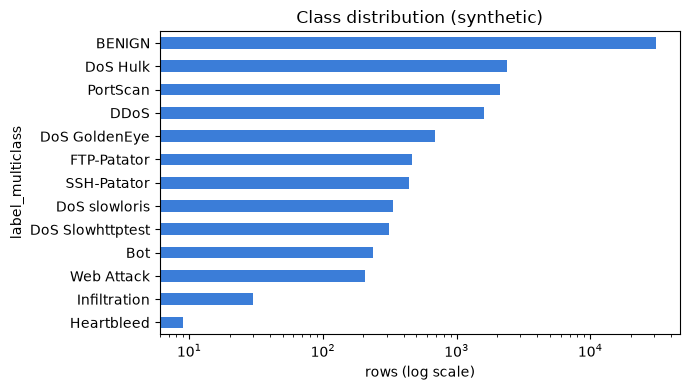

In [2]:
counts = df[MULTICLASS_TARGET].value_counts()
display(counts.to_frame("count"))
ax = counts.iloc[::-1].plot.barh(figsize=(7, 4), color="#3b7dd8")
ax.set(title="Class distribution (synthetic)", xlabel="rows (log scale)")
ax.set_xscale("log")
plt.tight_layout(); plt.show()

## 2. Missingness — concentrated and explainable
NaNs come from Inf on zero-duration flows (rate columns) and a few injected gaps.

In [3]:
miss = (df.isna().mean() * 100).round(3)
miss = miss[miss > 0].sort_values(ascending=False)
print("Columns with missing values (%):")
display(miss.to_frame("percent_missing"))
print("Impute with the median, fit on TRAIN only (done in the feature pipeline).")

Columns with missing values (%):


,percent_missing
Flow Bytes/s,2.062
Flow Packets/s,2.062
Flow IAT Std,0.495


Impute with the median, fit on TRAIN only (done in the feature pipeline).


## 3. Feature signal — present but not separable
No single feature is a perfect separator; a too-good model would imply leakage.

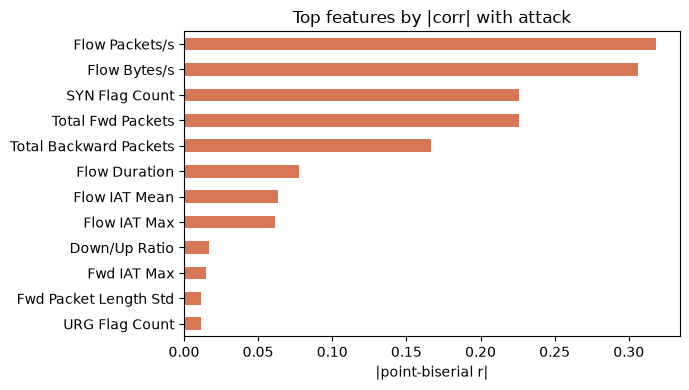

In [4]:
X = df[features].fillna(df[features].median())
corr = X.apply(lambda c: np.corrcoef(c, df[BINARY_TARGET])[0, 1] if c.std() > 0 else 0.0)
top = corr.abs().sort_values(ascending=False).head(12)
ax = top.iloc[::-1].plot.barh(figsize=(7, 4), color="#d77757")
ax.set(title="Top features by |corr| with attack", xlabel="|point-biserial r|")
plt.tight_layout(); plt.show()

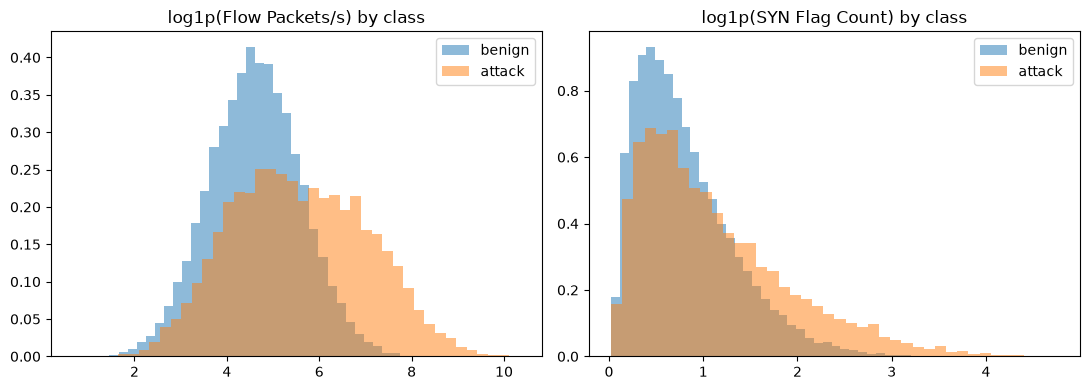

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ["Flow Packets/s", "SYN Flag Count"]):
    for name, sub in (("benign", df[df[BINARY_TARGET] == 0]), ("attack", df[df[BINARY_TARGET] == 1])):
        ax.hist(np.log1p(sub[feat].clip(lower=0)), bins=40, alpha=0.5, label=name, density=True)
    ax.set(title=f"log1p({feat}) by class"); ax.legend()
plt.tight_layout(); plt.show()

## 4. `Destination Port` — the leakage trap, made visible
Attack rate varies wildly by port; a model given the raw port can memorise it.

In [6]:
port_rate = df.groupby("Destination Port")[BINARY_TARGET].agg(["mean", "count"])
display(port_rate.sort_values("count", ascending=False).head(10).round(3))
print("Uneven attack-rate-by-port is why Destination Port is dropped from the headline model.")

,mean,count
Destination Port,,
80,0.617,8965
22,0.111,3941
8080,0.065,3660
143,0.000,3500
443,0.003,3489
25,0.000,3482
993,0.000,3469
110,0.000,3462
53,0.000,3421


Uneven attack-rate-by-port is why Destination Port is dropped from the headline model.


## Takeaways
1. **Imbalance** → PR-AUC, per-class recall, TPR@FPR; never accuracy. Use class weights.
2. **Missingness** → median impute, fit on train only.
3. **Signal** is moderate → expect honest metrics; a ~99.9% score means *audit for leakage*.
4. **Destination Port** is predictive via memorisation → dropped from the headline model;
   a port-keeping variant is reported separately to quantify the gap.